In [1]:
import numpy as np
import sys
import muram as mio  
import matplotlib.pyplot as plt

# Set font size 
plt.rcParams.update({'font.size': 15})

In [2]:
# For the SSD data with ch and corona - you can use this path:
#pathsource = '/dat/milic/MURaM_enhanced_network/'
#pathsource = '/dat/milic/'
pathsource = '/dat/milic/SSD_6x3Mm_2km/SSD_6x3Mm_2km/'
#path3D = pathsource + '3D/3D_full_subdomain'
path2D = pathsource + '2D/'

In [3]:
# IF you used the first one, it's FULL snaps - so use MuramSnap
#cube = mio.MuramSnap(path3D, 0)
# But for the other one, they are so called SUBSNAPS - so you use MuramSubSnap
slice = mio.MuramTauSlice(path2D, 0, 1.0)
int = mio.MuramIntensity(path2D, 0)

In [4]:
int.shape
int /= np.mean(int)

In [5]:
NX, NY = int.shape
x = np.arange(0, NX)*2.0  # in Km
y = np.arange(0, NY)*2.0  # in Km

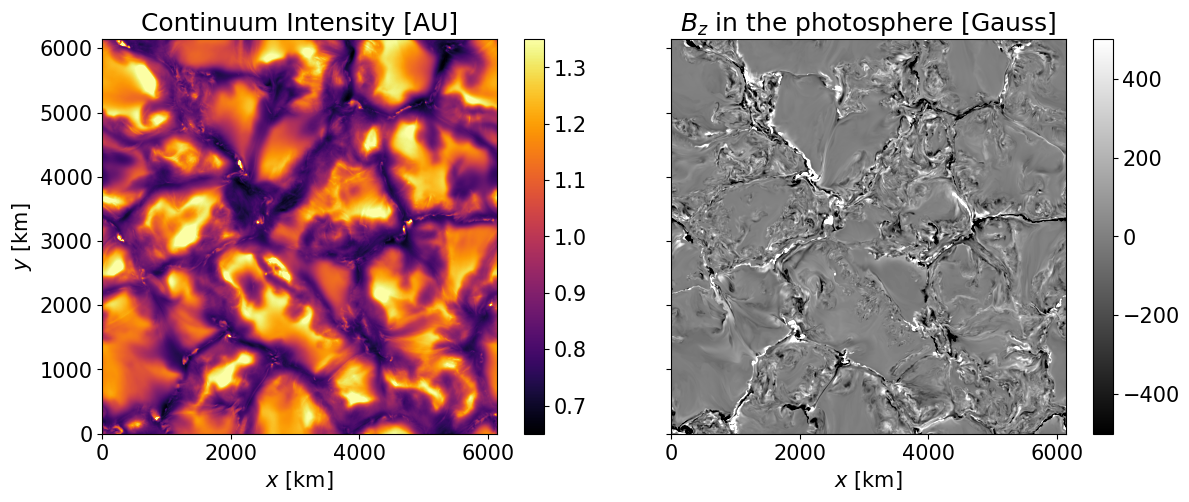

In [6]:
# Now let's make a plot of 2D intensity and 2D magnetic field if we can: 
plt.figure(figsize=(12.7,5))
plt.subplot(1,2,1)
plt.imshow(int.T, cmap='inferno', origin='lower', vmin = 0.65, vmax = 1.35, extent=[x.min(), x.max(), y.min(), y.max()])
plt.colorbar()
plt.title('Continuum Intensity [AU]')
plt.xlabel('$x$ [km]')
plt.ylabel('$y$ [km]')
plt.subplot(1,2,2)
plt.imshow(slice.By.T, cmap='gray', origin='lower', vmin=-500, vmax=500, extent=[x.min(), x.max(), y.min(), y.max()])
plt.colorbar()
plt.title('$B_z$ in the photosphere [Gauss]')
plt.xlabel('$x$ [km]')
#plt.ylabel('Y [pixels]')
# Hide the y tickmarks
plt.gca().set_yticklabels([])

plt.tight_layout()

In [7]:
B = np.sqrt(slice.Bx**2 + slice.By**2 + slice.Bz**2)

print('RMS B field at tau=1:', np.sqrt(np.mean(B**2)), 'Gauss')

RMS B field at tau=1: 233.05508 Gauss


In [8]:
# Now let's use astropy to smear the Bx, By, Bz to a lower resolution, we will use a Airy Disk PSF 
from astropy.convolution import convolve, AiryDisk2DKernel
resolution = 0.1 * 725 / 2.0  # In pixels
resolution = 50.0 / 2.0
kernel = AiryDisk2DKernel(resolution,x_size=71, y_size=71)  # 2.0 pixels FWHM
print(resolution)
print(kernel.shape)

25.0
(71, 71)


In [9]:
Bzc = convolve(slice.Bz, kernel, normalize_kernel=True)
Bxc = convolve(slice.Bx, kernel, normalize_kernel=True)
Byc = convolve(slice.By, kernel, normalize_kernel=True)

In [10]:
Ic = convolve(int, kernel, normalize_kernel=True)

RMS B field at tau=1 after smearing: 157.9226 Gauss


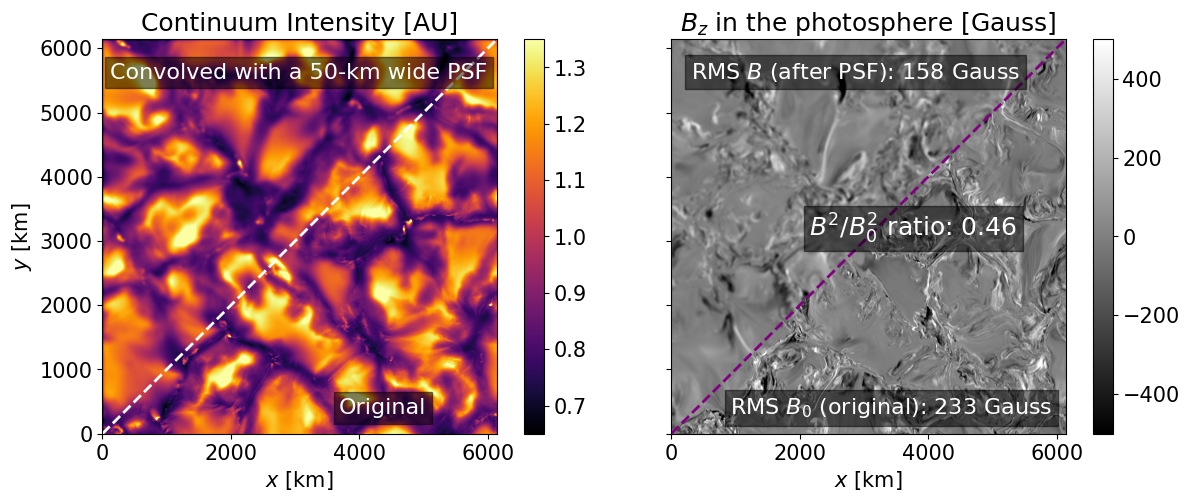

In [11]:
# Now do a plot where B_z is half smeared half not smeared, with a diagonal line 
# Create a mask for the diagonal

mask = np.fromfunction(lambda i, j: i > j, Bzc.shape)

plt.figure(figsize=(12.7,5))
plt.subplot(1,2,1)
I_mixed = np.zeros(int.shape)
I_mixed[~mask] = Ic[~mask]
I_mixed[mask] = int[mask]
plt.plot([x.min(), x.max()], [y.min(), y.max()], color='white', linestyle='--', linewidth=2)
plt.imshow(I_mixed.T, cmap='inferno', origin='lower', vmin = 0.65, vmax = 1.35, extent=[x.min(), x.max(), y.min(), y.max()])
# Put also some text indicating which side is smeared and which is not
plt.text(x.max()*0.02, y.max()*0.9, 'Convolved with a 50-km wide PSF', color='white', fontsize=16, bbox=dict(facecolor='black', alpha=0.5))
plt.text(x.max()*0.6, y.max()*0.05, 'Original', color='white', fontsize=16, bbox=dict(facecolor='black', alpha=0.5))    
plt.colorbar()
plt.title('Continuum Intensity [AU]')
plt.xlabel('$x$ [km]')
plt.ylabel('$y$ [km]')
plt.subplot(1,2,2)
# Create an array to hold the mixed data
Bz_mixed = np.zeros(Bzc.shape)
# Fill in the mixed array with smeared and unsmeared data
Bz_mixed[~mask] = Bzc[~mask]
Bz_mixed[mask] = slice.Bz[mask]
plt.imshow(Bz_mixed.T, cmap='gray', origin='lower', vmin=-500, vmax=500, extent=[x.min(), x.max(), y.min(), y.max()])
# Add a diagonal line
plt.plot([x.min(), x.max()], [y.min(), y.max()], color='purple', linestyle='--', linewidth=2)

# And add text which states the RMS B field before and after smearing
Bc = np.sqrt(Bxc**2 + Byc**2 + Bzc**2)
print('RMS B field at tau=1 after smearing:', np.sqrt(np.mean(Bc**2)), 'Gauss')
plt.text(x.max()*0.05, y.max()*0.9, f'RMS $B$ (after PSF): {np.sqrt(np.mean(Bc**2)):.0f} Gauss', color='white', fontsize=16, bbox=dict(facecolor='black', alpha=0.5))

plt.text(x.max()*0.15, y.max()*0.05, f'RMS $B_0$ (original): {np.sqrt(np.mean(B**2)):.0f} Gauss', color='white', fontsize=16, bbox=dict(facecolor='black', alpha=0.5))

# And in between them add ratio of mean squared B fields
ratio = (np.mean(Bc**2)) / (np.mean(B**2))
plt.text(x.max()*0.35, y.max()*0.5, f'$B^2/B_0^2$ ratio: {ratio:.2f}', color='white', fontsize=18, bbox=dict(facecolor='black', alpha=0.5))


plt.colorbar()
plt.title('$B_z$ in the photosphere [Gauss]')
plt.xlabel('$x$ [km]')
#plt.ylabel('Y [pixels]')
# Hide the y tickmarks
plt.gca().set_yticklabels([])
plt.tight_layout()
plt.savefig('muram_2D_intensity_Bz_smearing.png', dpi=300, bbox_inches='tight')

In [12]:
Bc = np.sqrt(Bxc**2 + Byc**2 + Bzc**2)
print('RMS B field at tau=1 after smearing:', np.sqrt(np.mean(Bc**2)), 'Gauss')

RMS B field at tau=1 after smearing: 157.9226 Gauss


/tmp/ipykernel_331812/2106193438.py:49: UserWarning: This figure was using a layout engine that is incompatible with subplots_adjust and/or tight_layout; not calling subplots_adjust.
  plt.subplots_adjust(wspace=0.02, left=0, right=1, top=1, bottom=0)


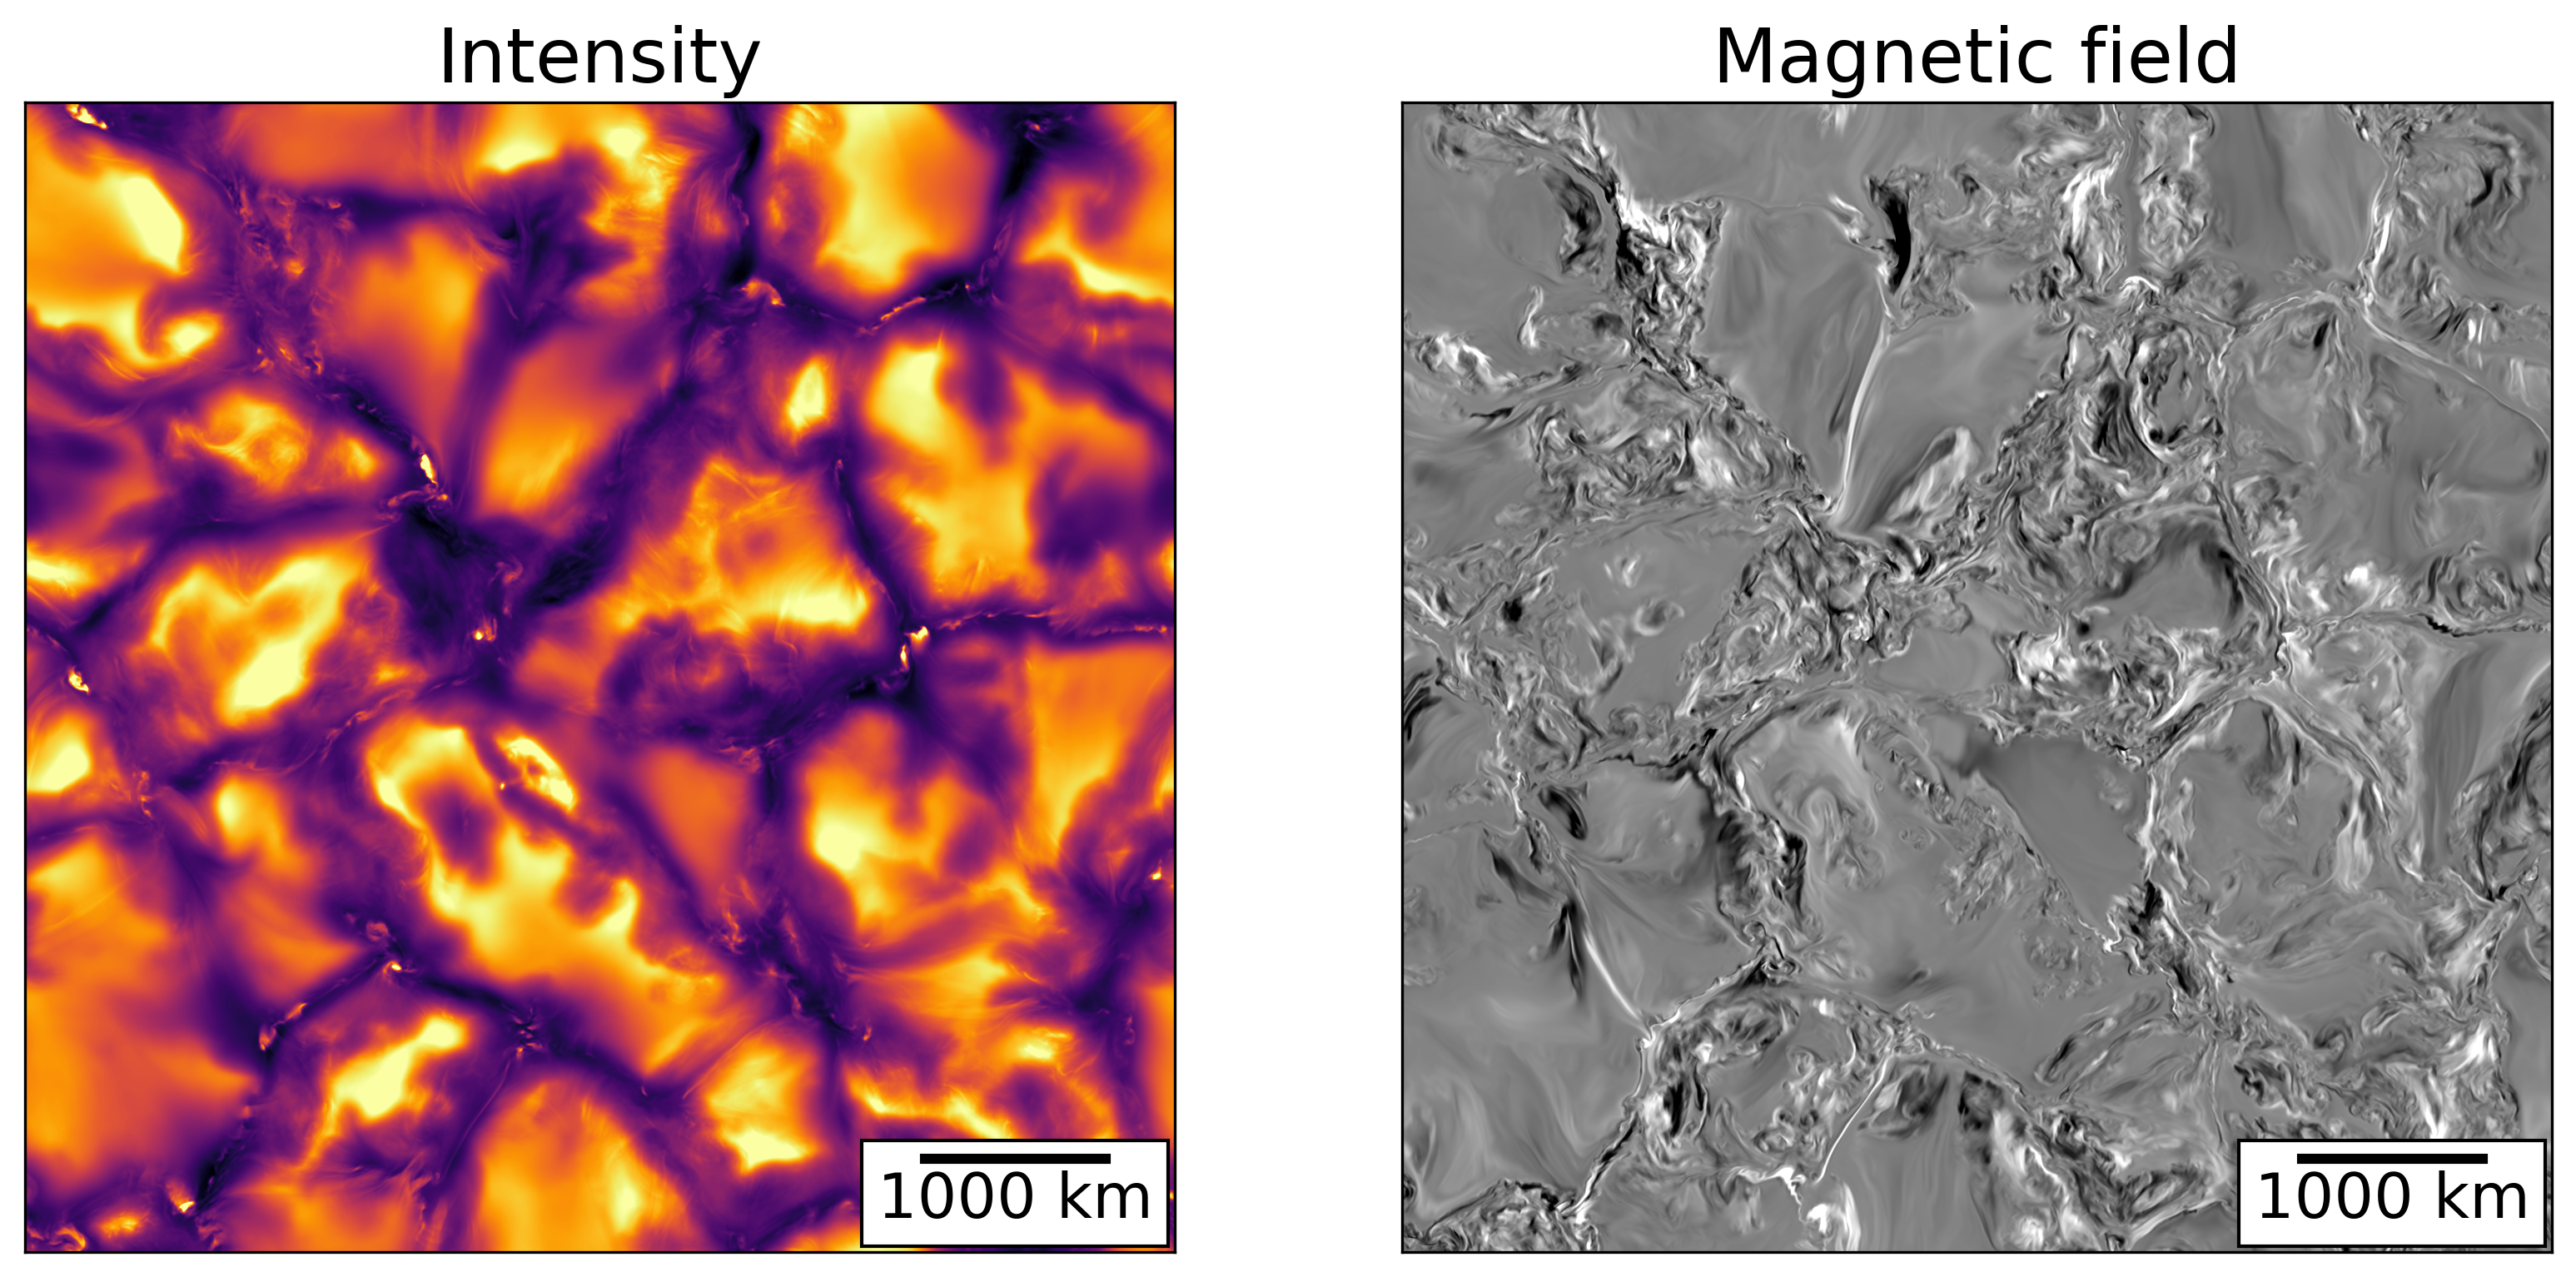

In [23]:
from mpl_toolkits.axes_grid1.anchored_artists import AnchoredSizeBar

import matplotlib.font_manager as fm

plt.rcParams.update({'font.size': 18})
fig, axs = plt.subplots(
    1, 2,
    figsize=(11, 5),
    dpi=300,
    constrained_layout=True
)

# Common plotting limits in physical units (km)
extent = [x.min(), x.max(), y.min(), y.max()]
scale_km = 1000  # physical scale bar length

# Intensity (original, no smearing)
axs[0].imshow(
    int.T, cmap='inferno', origin='lower',
    vmin=0.65, vmax=1.35, extent=extent
)

# Bz (original, no smearing)
axs[1].imshow(
    slice.Bz.T, cmap='gray', origin='lower',
    vmin=-500, vmax=500, extent=extent
)

axs[0].set_title('Intensity')
axs[1].set_title('Magnetic field')

for ax in axs:
    # remove axes, ticks, labels
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_xlabel('')
    ax.set_ylabel('')
    for spine in ax.spines.values():
        spine.set_visible(True)

    # add physical scale bar (no box)
    scalebar = AnchoredSizeBar(
        ax.transData, scale_km, f'{scale_km} km', 'lower right',
        pad=0.25, color='black', frameon=True, size_vertical=36,
        fontproperties=fm.FontProperties(size=18)
    )
    ax.add_artist(scalebar)

plt.subplots_adjust(wspace=0.02, left=0, right=1, top=1, bottom=0)
plt.savefig('muram_2D_intensity_Bz_clean.png', dpi=300, bbox_inches='tight', pad_inches=0)
plt.show()

/tmp/ipykernel_331812/494320603.py:49: UserWarning: This figure was using a layout engine that is incompatible with subplots_adjust and/or tight_layout; not calling subplots_adjust.
  plt.subplots_adjust(wspace=0.02, left=0, right=1, top=1, bottom=0)


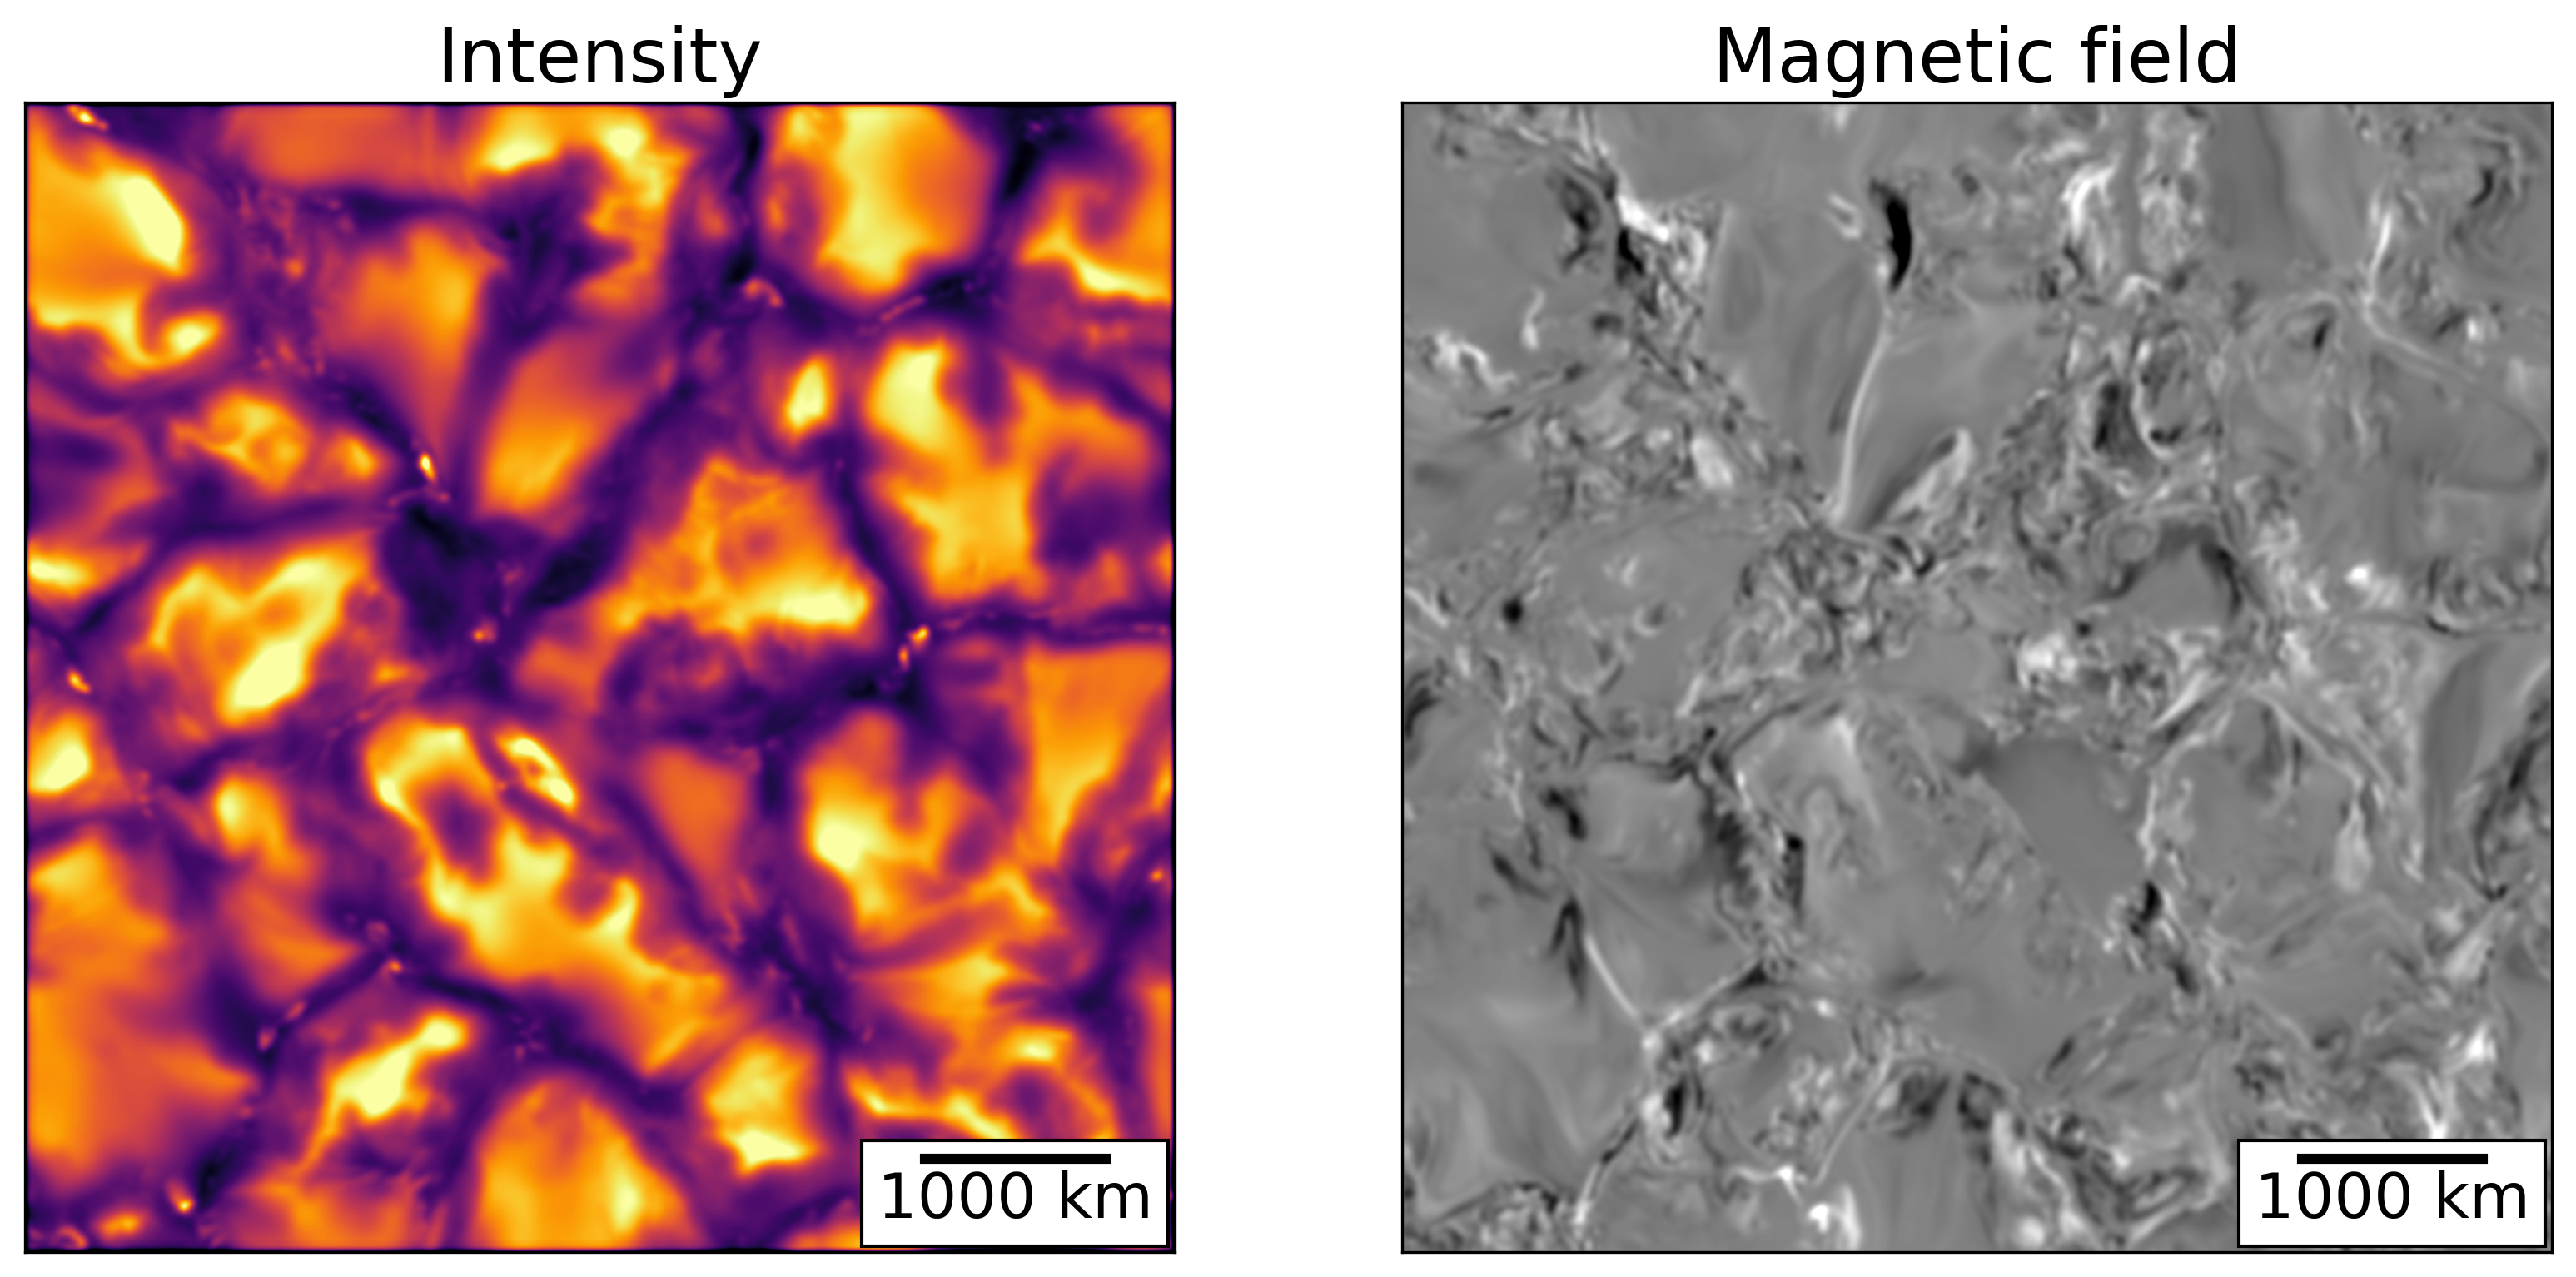

In [24]:
from mpl_toolkits.axes_grid1.anchored_artists import AnchoredSizeBar

import matplotlib.font_manager as fm

plt.rcParams.update({'font.size': 18})
fig, axs = plt.subplots(
    1, 2,
    figsize=(11, 5),
    dpi=300,
    constrained_layout=True
)

# Common plotting limits in physical units (km)
extent = [x.min(), x.max(), y.min(), y.max()]
scale_km = 1000  # physical scale bar length

# Intensity (original, no smearing)
axs[0].imshow(
    Ic.T, cmap='inferno', origin='lower',
    vmin=0.65, vmax=1.35, extent=extent
)

# Bz (original, no smearing)
axs[1].imshow(
    Bzc.T, cmap='gray', origin='lower',
    vmin=-500, vmax=500, extent=extent
)

axs[0].set_title('Intensity')
axs[1].set_title('Magnetic field')

for ax in axs:
    # remove axes, ticks, labels
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_xlabel('')
    ax.set_ylabel('')
    for spine in ax.spines.values():
        spine.set_visible(True)

    # add physical scale bar (no box)
    scalebar = AnchoredSizeBar(
        ax.transData, scale_km, f'{scale_km} km', 'lower right',
        pad=0.25, color='black', frameon=True, size_vertical=36,
        fontproperties=fm.FontProperties(size=18)
    )
    ax.add_artist(scalebar)

plt.subplots_adjust(wspace=0.02, left=0, right=1, top=1, bottom=0)
plt.savefig('muram_2D_intensity_Bz_clean_convolved.png', dpi=300, bbox_inches='tight', pad_inches=0)
plt.show()